# Recommendation Systems — Market Basket Analysis

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ujjwal091/ai-ml-course/blob/main/modules/02-unsupervised-learning/market-basket-analysis/notes.ipynb)

*"If a customer buys X, are they likely to buy Y?"*


## 1. Where this fits

Market basket analysis is the "if the user bought `X`, will they buy `Y`?" side of recommendation. It is
**unsupervised** — there is no `y` column. We only have purchase history, and we look for patterns in it. (The
other side — giving every user their own personal score for every item — is in
[Recommender Systems](../recommender-systems/notes.ipynb).)

**The data**: same Veloura fashion retailer as the other notebooks. Every row of the billing system is one item on
one invoice. We want to find which products are bought together.


## 2. Transactional data

Billing data looks like this — one row per item, many rows per invoice:


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations

bill = pd.DataFrame({
    "invoice": ["INV-1", "INV-1", "INV-2", "INV-2", "INV-2"],
    "item":    ["jeans", "belt", "sneakers", "socks", "jeans"],
    "qty":     [1, 1, 1, 3, 1],
})
bill

,invoice,item,qty
0,INV-1,jeans,1
1,INV-1,belt,1
2,INV-2,sneakers,1
3,INV-2,socks,3
4,INV-2,jeans,1


To find patterns we need **one row per invoice**, showing which items were in it. Quantity doesn't matter here —
only *was the item in the basket or not*. Three pairs of socks counts the same as one.


In [2]:
basket_matrix = pd.crosstab(bill["invoice"], bill["item"]).clip(upper=1)
basket_matrix

item,belt,jeans,sneakers,socks
invoice,,,,
INV-1,1,1,0,0
INV-2,0,1,1,1


## 3. Why we can't just check every combination

A store sells `N` products. A basket can hold any combination of them. The number of possible non-empty
combinations (called **itemsets**) is:

$$
2^N - 1
$$

With 3 products (A, B, C) that's 7: `A, B, C, AB, AC, BC, ABC`. Small. Now see how fast it grows:


In [3]:
for n in [3, 10, 30, 100]:
    print(f"N = {n:>3} products  →  {2**n - 1:,} possible itemsets")

N =   3 products  →  7 possible itemsets
N =  10 products  →  1,023 possible itemsets
N =  30 products  →  1,073,741,823 possible itemsets
N = 100 products  →  1,267,650,600,228,229,401,496,703,205,375 possible itemsets


A typical store has about 100 products. That's more combinations than anyone can count — checking each one is
impossible. So the whole topic is about **throwing away combinations early**, using a simple rule (Section 7).


## 4. Terminology

- **Item** — one product. The set of all products is $I = \{i_1, i_2, \dots, i_n\}$.
- **Transaction** — one basket (one invoice). A subset of $I$, e.g. $T_1 = \{\text{jeans}, \text{belt}\}$.
- **Database** — all transactions together: $D = \{T_1, T_2, T_3, \dots\}$.
- **Itemset** — any group of items, e.g. `{jeans, belt}`.

**Association rule**: written $\{A\} \Rightarrow \{B\}$, read "if a customer buys `A`, they are likely to also buy
`B`". `A` is the **antecedent** (the "if" side), `B` is the **consequent** (the "then" side).

Both sides can hold more than one item: $\{\text{jeans}, \text{sneakers}\} \Rightarrow \{\text{belt}\}$.

The data below is 2,000 made-up Veloura invoices. Gift wrap is added to most baskets, belts tend to go with
jeans, and socks tend to go with sneakers — the patterns we hope the math will find.


In [4]:
def build_transactions(n=2000, seed=11):
    rng = np.random.default_rng(seed)
    baskets = []
    for _ in range(n):
        b = set()
        if rng.random() < 0.80: b.add("gift_wrap")
        if rng.random() < 0.30:
            b.add("jeans")
            if rng.random() < 0.60: b.add("belt")
        if rng.random() < 0.35:
            b.add("sneakers")
            if rng.random() < 0.70: b.add("socks")
        if rng.random() < 0.30: b.add("tshirt")
        if rng.random() < 0.12: b.add("jacket")
        if rng.random() < 0.15: b.add("cap")
        if rng.random() < 0.08: b.add("perfume")
        if rng.random() < 0.05: b.add("scarf")
        if not b:
            b.add("tshirt")
        baskets.append(frozenset(b))
    return baskets

transactions = build_transactions()
N = len(transactions)
print(f"{N} invoices. First 5 baskets:")
for t in transactions[:5]:
    print("  ", sorted(t))

2000 invoices. First 5 baskets:
   ['gift_wrap', 'perfume', 'tshirt']
   ['tshirt']
   ['gift_wrap']
   ['gift_wrap', 'sneakers']
   ['perfume', 'sneakers', 'socks', 'tshirt']


## 5. The three numbers: support, confidence, lift

For a rule $A \Rightarrow B$:

| Metric | Question it answers | Formula |
|---|---|---|
| **Support** | How common is this combination? | $\dfrac{\text{baskets with A and B}}{\text{all baskets}}$ |
| **Confidence** | When `A` is bought, how often is `B` also bought? | $\dfrac{\text{baskets with A and B}}{\text{baskets with A}}$ |
| **Lift** | Is the link real, or just luck? | $\dfrac{\text{confidence}(A \Rightarrow B)}{\text{support}(B)}$ |

Confidence is just conditional probability, $P(B \mid A)$. Lift compares it against how often `B` gets bought
anyway.

Let's do it by hand for **jeans ⇒ belt**, counting baskets first:


In [5]:
def count(itemset):
    return sum(set(itemset) <= t for t in transactions)

n_jeans, n_belt, n_both = count({"jeans"}), count({"belt"}), count({"jeans", "belt"})
print(f"Baskets total:          {N}")
print(f"Baskets with jeans:     {n_jeans}")
print(f"Baskets with belt:      {n_belt}")
print(f"Baskets with both:      {n_both}")
print()
support = n_both / N
confidence = n_both / n_jeans
lift = confidence / (n_belt / N)
print(f"Support    = {n_both} / {N}        = {support:.3f}")
print(f"Confidence = {n_both} / {n_jeans}         = {confidence:.3f}")
print(f"Lift       = {confidence:.3f} / {n_belt / N:.3f}     = {lift:.2f}")

Baskets total:          2000
Baskets with jeans:     619
Baskets with belt:      376
Baskets with both:      376

Support    = 376 / 2000        = 0.188
Confidence = 376 / 619         = 0.607
Lift       = 0.607 / 0.188     = 3.23


Reading it: 18.8% of all baskets have both (support). Of the people who bought jeans, 60.7% also bought a belt
(confidence). And belts are bought in only 18.8% of baskets overall, so 60.7% is about **3.2 times** higher than
chance (lift).

**How to read lift:**
- **Lift > 1** — bought together *more* than chance. Real link.
- **Lift = 1** — no relationship. Independent.
- **Lift < 1** — bought together *less* than chance. Buying one makes the other less likely.

Also note that rules are **not symmetric**. `belt ⇒ jeans` has a different confidence than `jeans ⇒ belt`,
because the denominator changes (belt buyers vs. jeans buyers). Lift, however, is the same both ways.


In [6]:
def rule_metrics(a, b):
    both = count(set(a) | set(b))
    sup = both / N
    conf = both / count(a)
    lift = conf / (count(b) / N)
    return sup, conf, lift

pairs = [({"jeans"}, {"belt"}), ({"belt"}, {"jeans"}),
         ({"sneakers"}, {"socks"}), ({"socks"}, {"sneakers"})]
pd.DataFrame(
    [(f"{set(a)} ⇒ {set(b)}", *rule_metrics(a, b)) for a, b in pairs],
    columns=["rule", "support", "confidence", "lift"],
).round(3)

,rule,support,confidence,lift
0,{'jeans'} ⇒ {'belt'},0.188,0.607,3.231
1,{'belt'} ⇒ {'jeans'},0.188,1.000,3.231
2,{'sneakers'} ⇒ {'socks'},0.246,0.687,2.793
3,{'socks'} ⇒ {'sneakers'},0.246,1.000,2.793


`belt ⇒ jeans` has confidence **1.0** — every single belt buyer also bought jeans. But `jeans ⇒ belt` is only
0.61. Same pair of items, very different confidence. Lift is identical (3.23) in both directions.


## 6. The confidence trap

Confidence alone can fool you. Look at gift wrap — 80% of all baskets have it. Check `jeans ⇒ gift_wrap`:


In [7]:
for a, b in [({"jeans"}, {"gift_wrap"}), ({"belt"}, {"gift_wrap"}), ({"scarf"}, {"gift_wrap"})]:
    s, c, l = rule_metrics(a, b)
    print(f"{str(set(a)):>12} ⇒ {str(set(b)):<14} confidence = {c:.2f}   lift = {l:.2f}")

print(f"\nGift wrap appears in {count({'gift_wrap'}) / N:.0%} of ALL baskets.")

   {'jeans'} ⇒ {'gift_wrap'}  confidence = 0.81   lift = 1.02
    {'belt'} ⇒ {'gift_wrap'}  confidence = 0.81   lift = 1.02
   {'scarf'} ⇒ {'gift_wrap'}  confidence = 0.78   lift = 0.98

Gift wrap appears in 80% of ALL baskets.


Confidence looks great — 81% of jeans buyers also buy gift wrap! But lift is about **1.0**. That's because 80%
of *everyone* buys gift wrap. Jeans buyers are no more likely to buy it than anybody else.

This is exactly why lift exists. A rule with high confidence but lift ≈ 1 is just stating that the consequent is
popular. It is not a useful recommendation. **Always check lift before trusting a rule.**


## 7. Pruning — how to avoid checking 2ᴺ combinations

Back to the 2ᴺ − 1 problem. The trick is one simple fact:

> If an item is rare, any combination containing it is **at least as rare**.

If avocado shows up in only 10% of baskets, then {avocado, bread} can't show up in more than 10% of baskets
either. So if we decide a combination needs at least **10% support** to be worth looking at, we can throw away
avocado *and every combination containing it* — without checking any of them.

This is the **Apriori principle**. Steps:

1. Count support for every **single item**. Drop those below the minimum support.
2. Build **pairs only from the survivors**. Count them. Drop the weak ones.
3. Build **triples only from surviving pairs**. And so on, until nothing survives.

Let's start with step 1, minimum support = 10%:


In [8]:
MIN_SUPPORT = 0.10

all_items = sorted(set().union(*transactions))
item_support = pd.Series({i: count({i}) / N for i in all_items}).sort_values(ascending=False)
item_support.round(3).to_frame("support")

,support
gift_wrap,0.800
sneakers,0.358
tshirt,0.346
jeans,0.310
socks,0.246
belt,0.188
cap,0.154
jacket,0.126
perfume,0.082
scarf,0.048


In [9]:
frequent_items = item_support[item_support >= MIN_SUPPORT].index.tolist()
dropped = [i for i in all_items if i not in frequent_items]
print("Kept:   ", frequent_items)
print("Dropped:", dropped)

Kept:    ['gift_wrap', 'sneakers', 'tshirt', 'jeans', 'socks', 'belt', 'cap', 'jacket']
Dropped: ['perfume', 'scarf']


`perfume` (8.3%) and `scarf` (4.8%) are gone. Any combination containing them is gone too.

Now let's see how much work that saved. Without pruning we'd check every combination of all 10 items. With
pruning, only the combinations of the 8 survivors:


In [10]:
print(f"All 10 items, no pruning:  {2**len(all_items) - 1:,} itemsets to check")
print(f"After dropping 2 items:    {2**len(frequent_items) - 1:,} itemsets to check")

All 10 items, no pruning:  1,023 itemsets to check
After dropping 2 items:    255 itemsets to check


Only 2 items dropped, and we already skip about 75% of the work. With 100 real products, where most are rare,
the savings are enormous. And this was only step 1 — pruning at the pair level and beyond cuts it even more.

First, the whole procedure on a tiny table you can check by eye. Five baskets, minimum support 60% (an itemset
must appear in at least 3 of 5 baskets):


In [11]:
tiny = [
    frozenset({"jeans", "tee"}),
    frozenset({"jeans", "belt", "socks", "scarf"}),
    frozenset({"jeans", "belt", "socks", "tee"}),
    frozenset({"belt", "socks", "tee"}),
    frozenset({"jeans", "belt", "socks"}),
]
pd.DataFrame([{i: int(i in t) for i in sorted(set().union(*tiny))} for t in tiny],
             index=[f"T{k}" for k in range(1, 6)])

,belt,jeans,scarf,socks,tee
T1,0,1,0,0,1
T2,1,1,1,1,0
T3,1,1,0,1,1
T4,1,0,0,1,1
T5,1,1,0,1,0


**Step 1 — single items.** Count each, drop anything under 3 baskets.


In [12]:
def tiny_count(itemset):
    return sum(set(itemset) <= t for t in tiny)

step1 = pd.DataFrame({
    "baskets": {i: tiny_count({i}) for i in sorted(set().union(*tiny))},
})
step1["support"] = step1["baskets"] / len(tiny)
step1["verdict"] = np.where(step1["support"] >= 0.6, "keep", "PRUNED")
step1

,baskets,support,verdict
belt,4,0.8,keep
jeans,4,0.8,keep
scarf,1,0.2,PRUNED
socks,4,0.8,keep
tee,3,0.6,keep


`scarf` appears once (20%), so it is dropped — and with it every combination containing scarf.

**Step 2 — pairs, built only from survivors.**


In [13]:
survivors = list(step1[step1["verdict"] == "keep"].index)
step2 = pd.DataFrame(
    [{"pair": set(p), "baskets": tiny_count(p)} for p in combinations(survivors, 2)]
)
step2["support"] = step2["baskets"] / len(tiny)
step2["verdict"] = np.where(step2["support"] >= 0.6, "keep", "PRUNED")
step2

,pair,baskets,support,verdict
0,"{jeans, belt}",3,0.6,keep
1,"{socks, belt}",4,0.8,keep
2,"{tee, belt}",2,0.4,PRUNED
3,"{socks, jeans}",3,0.6,keep
4,"{jeans, tee}",2,0.4,PRUNED
5,"{socks, tee}",2,0.4,PRUNED


**Step 3 — triples, built only from the surviving pairs.** Then rules from whatever survives. Take the rule
`{belt, socks} ⇒ {jeans}`:


In [14]:
triple = {"belt", "socks", "jeans"}
sup_triple = tiny_count(triple) / len(tiny)
conf = tiny_count(triple) / tiny_count({"belt", "socks"})
lift = conf / (tiny_count({"jeans"}) / len(tiny))
print(f"support    = {tiny_count(triple)}/5          = {sup_triple:.2f}")
print(f"confidence = {tiny_count(triple)}/{tiny_count({'belt', 'socks'})}          = {conf:.2f}")
print(f"lift       = {conf:.2f} / {tiny_count({'jeans'}) / len(tiny):.2f}   = {lift:.2f}")

support    = 3/5          = 0.60
confidence = 3/4          = 0.75
lift       = 0.75 / 0.80   = 0.94


Support 60% (common enough), confidence 75% (3 of 4 belt-and-socks baskets had jeans), lift 0.94 — a touch
**below** 1. Jeans are so common in this tiny table (80%) that "belt and socks" doesn't make them any likelier.
This rule passes the support filter yet is not a real link. That's why the lift check always comes last.

Now the full from-scratch version:


In [15]:
def apriori(transactions, min_support):
    n = len(transactions)
    freq = {}  # itemset -> support

    singles = {}
    for t in transactions:
        for i in t:
            singles[frozenset([i])] = singles.get(frozenset([i]), 0) + 1
    current = {s: c / n for s, c in singles.items() if c / n >= min_support}
    freq.update(current)

    k = 2
    while current:
        survivors = list(current)
        # build candidates of size k only by joining surviving (k-1)-itemsets
        candidates = {a | b for a in survivors for b in survivors if len(a | b) == k}
        counts = {c: 0 for c in candidates}
        for t in transactions:
            for c in candidates:
                if c <= t:
                    counts[c] += 1
        current = {c: v / n for c, v in counts.items() if v / n >= min_support}
        freq.update(current)
        k += 1
    return freq

frequent_itemsets = apriori(transactions, MIN_SUPPORT)
print(f"{len(frequent_itemsets)} frequent itemsets found at min support {MIN_SUPPORT:.0%}")

by_size = pd.Series([len(s) for s in frequent_itemsets]).value_counts().sort_index()
by_size.rename_axis("itemset size").to_frame("how many")

21 frequent itemsets found at min support 10%


,how many
itemset size,
1,8
2,11
3,2


## 8. From frequent itemsets to rules

Each frequent itemset can be split into "if" and "then" parts. For `{jeans, belt}` that gives two rules:
`jeans ⇒ belt` and `belt ⇒ jeans`. We compute confidence and lift for each, and keep the good ones.


In [16]:
def make_rules(frequent_itemsets, min_confidence=0.5):
    rules = []
    for itemset, sup in frequent_itemsets.items():
        if len(itemset) < 2:
            continue
        for r in range(1, len(itemset)):
            for antecedent in map(frozenset, combinations(itemset, r)):
                consequent = itemset - antecedent
                conf = sup / frequent_itemsets[antecedent]
                lift = conf / frequent_itemsets[consequent]
                if conf >= min_confidence:
                    rules.append((set(antecedent), set(consequent), sup, conf, lift))
    return pd.DataFrame(rules, columns=["if (antecedent)", "then (consequent)", "support", "confidence", "lift"])

rules = make_rules(frequent_itemsets, min_confidence=0.5)
rules.sort_values("lift", ascending=False).round(3).reset_index(drop=True)

,if (antecedent),then (consequent),support,confidence,lift
0,"{gift_wrap, jeans}",{belt},0.153,0.608,3.236
1,{belt},"{gift_wrap, jeans}",0.153,0.814,3.236
2,{jeans},{belt},0.188,0.607,3.231
3,{belt},{jeans},0.188,1.000,3.231
4,"{gift_wrap, belt}",{jeans},0.153,1.000,3.231
5,"{gift_wrap, sneakers}",{socks},0.200,0.704,2.860
6,{socks},"{gift_wrap, sneakers}",0.200,0.815,2.860
7,{sneakers},"{gift_wrap, socks}",0.200,0.560,2.793
8,"{gift_wrap, socks}",{sneakers},0.200,1.000,2.793
9,{sneakers},{socks},0.246,0.687,2.793


Sorted by lift, the real patterns rise to the top: `belt ⇔ jeans` (lift 3.2) and `socks ⇔ sneakers` (lift 2.8).
Further down you'll see rules ending in `gift_wrap` with decent confidence but lift ≈ 1 — the trap from Section 6.

A simple filter keeps only rules that are *both* reliable and real:


In [17]:
good_rules = rules[(rules["confidence"] >= 0.6) & (rules["lift"] > 1.2)]
good_rules.sort_values("lift", ascending=False).round(3).reset_index(drop=True)

,if (antecedent),then (consequent),support,confidence,lift
0,{belt},"{gift_wrap, jeans}",0.153,0.814,3.236
1,"{gift_wrap, jeans}",{belt},0.153,0.608,3.236
2,"{gift_wrap, belt}",{jeans},0.153,1.000,3.231
3,{belt},{jeans},0.188,1.000,3.231
4,{jeans},{belt},0.188,0.607,3.231
5,{socks},"{gift_wrap, sneakers}",0.200,0.815,2.860
6,"{gift_wrap, sneakers}",{socks},0.200,0.704,2.860
7,{socks},{sneakers},0.246,1.000,2.793
8,{sneakers},{socks},0.246,0.687,2.793
9,"{gift_wrap, socks}",{sneakers},0.200,1.000,2.793


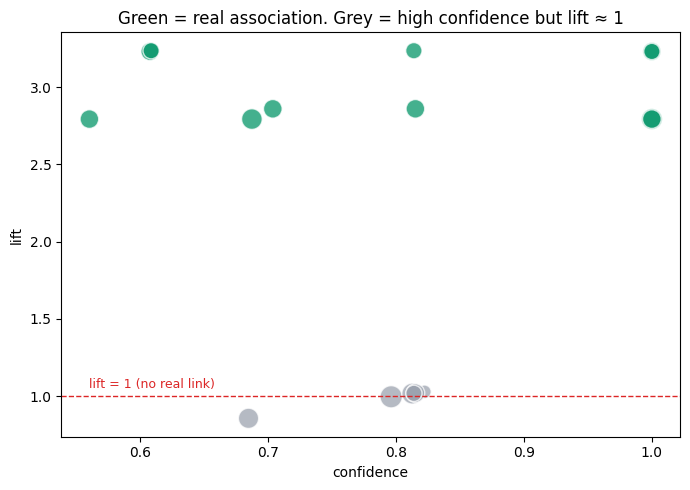

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#059669" if l > 1.2 else "#9ca3af" for l in rules["lift"]]
ax.scatter(rules["confidence"], rules["lift"], s=rules["support"] * 900, c=colors, alpha=0.75, edgecolor="white")
ax.axhline(1, color="#DC2626", ls="--", lw=1)
ax.text(rules["confidence"].min(), 1.05, "lift = 1 (no real link)", color="#DC2626", fontsize=9)
ax.set_xlabel("confidence")
ax.set_ylabel("lift")
ax.set_title("Green = real association. Grey = high confidence but lift ≈ 1")
plt.tight_layout()
plt.show()

## 9. Using the rules

Once you have good rules, the business uses them directly:

- **"Frequently bought together"** — customer has jeans in the cart → suggest a belt.
- **Bundling** — sell jeans + belt as one offer, since 3 in 5 jeans buyers already want the belt.
- **Store layout** — put belts near jeans. Or deliberately put them far apart, so customers walk past other items.
- **Cross-selling** — for sneakers, offer socks at checkout.

A small recommender using the rules table — given a cart, return the top suggestions:


In [19]:
def recommend(cart, rules_df, top_n=3):
    cart = set(cart)
    matches = [
        (row["lift"], next(iter(row["then (consequent)"])))
        for _, row in rules_df.iterrows()
        if row["if (antecedent)"] <= cart and not (row["then (consequent)"] & cart)
    ]
    matches.sort(reverse=True)
    return [item for _, item in matches][:top_n]

for cart in [{"jeans"}, {"sneakers"}, {"tshirt"}]:
    print(f"Cart {sorted(cart)}  →  suggest {recommend(cart, good_rules)}")

Cart ['jeans']  →  suggest ['belt']
Cart ['sneakers']  →  suggest ['socks']
Cart ['tshirt']  →  suggest []


`tshirt` gets no suggestion — no strong rule exists for it in this data, and that's the honest answer. A good
recommender should be quiet when it has nothing real to say.


## 10. Summary — revision cheat sheet

- **Recommendation** (this flavour) is unsupervised — no `y`, just purchase history.
- **Transaction** = one basket. **Itemset** = a group of items. **Rule** $A \Rightarrow B$ = "if `A`, then likely `B`".
- **Support** = how common is the combination. **Confidence** = $P(B \mid A)$, how reliable is the rule.
  **Lift** = confidence ÷ support(B), is it real or luck.
- **Lift > 1** real link, **= 1** independent, **< 1** negative link.
- **Confidence is not symmetric** (`A ⇒ B` ≠ `B ⇒ A`); **lift is**.
- **Confidence trap**: if `B` is bought by almost everyone, any rule ending in `B` has high confidence. Check lift.
- **2ᴺ − 1 itemsets** is too many to check. **Apriori pruning**: a rare item makes every combination containing it
  rare, so drop rare items first and build bigger combinations only from survivors.

**Next**: [Recommender Systems](../recommender-systems/notes.ipynb) — personal scores per user, instead of rules
for everyone.
